# Testing lj mass difference on siganl and background

In [1]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm
from coffea.processor import accumulate
import mplhep as hep
from helpers import merge_bkg, merge_cutflows
from helpers import *

In [9]:
vr  = "38"
outall = {}
bkgprocess = [
    "fmu1", "fmu2",
    "fmu3", "fmu4",
    "fmu5", "fmu6",
    "fmu7", "fmu8",
    "fmu9", "fmu0",
    "fmui", "fmux",
    "ttj",
    "dyj1",    "dyj2",
    "qcd1",    "qcd2",
    "qcd3",    "qcd4",
    "qcd5",    "qcd6",
    "qcd7",    "qcd8",
    "qcd9",    "qcd0",
    "qcdi",   "qcdx"
]
for p in bkgprocess:
    outp = coffea.util.load(f"outputs/bkg_{vr}_{p}.coffea")
    # print(f"outputs/bkg_32c_{p}.coffea")
    outall |= outp

coffea.util.save(outall, f"outputs/bkg_{vr}.coffea")

# for k in outall:
#     print(k)

In [10]:
output = coffea.util.load(f"outputs/bkg_{vr}.coffea")

In [11]:
# Channels
channels = [
    "bkg_2mulj_iso_disp_dphi",
    "bkg_2mulj_iso_disp_dphi_ljmp10",
    "bkg_2mulj_iso_disp_dphi_ljmp15",
    "bkg_2mulj_iso_disp_dphi_ljmp20"
    # "bkg_base_2mulj_iso_disp_dphi_mljd_mass175",
]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]
# ch4 = channels[3]
# ch5 = channels[4]
# ch6 = channels[5]

chan = [ch1, ch2, ch3,]
chaname = ["dphi>2", "ljm > 0.3", "ljm > 0.5"]#, "ljm > 0.3 + mljlj < 1"]
# chaname = ["base", "Iso", "Disp", "dphi>2", "mljdiff<0.2", "mjj>175"]

In [12]:
# signal
signal = ["4Mu_500GeV_1p2GeV_1p9mm","4Mu_800GeV_1p2GeV_1p2mm","4Mu_800GeV_5p0GeV_5p0mm","4Mu_800GeV_1p2GeV_6p0mm",]
# signal = ["4Mu_500GeV_1p2GeV_1p9mm","4Mu_800GeV_1p2GeV_1p2mm","4Mu_800GeV_5p0GeV_5p0mm","4Mu_800GeV_1p2GeV_6p0mm",]
# signal = [fmulxy8, ]
bkgttj = ["TTJets"]
bkgdyj = ["DYJetsToMuMu_M10to50", "DYJetsToMuMu_M50",]
bkgqcd = ["QCD_Pt15To20", "QCD_Pt20To30", "QCD_Pt30To50", "QCD_Pt50To80", "QCD_Pt80To120", "QCD_Pt120To170", "QCD_Pt170To300", "QCD_Pt300To470", "QCD_Pt470To600",
           "QCD_Pt600To800", "QCD_Pt800To1000", "QCD_Pt1000"]

sss = signal[2]
# print(sss)
figh, figw = 12, 10

# Start plotting

In [13]:
output = coffea.util.load(f"outputs/bkg_38.coffea")
for k in output:
    print(k)
# output

4Mu_200GeV_0p25GeV_10p0mm
4Mu_200GeV_0p25GeV_1p0mm
4Mu_200GeV_0p25GeV_5p0mm
4Mu_200GeV_0p25GeV_0p01mm
4Mu_200GeV_0p25GeV_0p1mm
4Mu_200GeV_1p2GeV_48p0mm
4Mu_200GeV_1p2GeV_24p0mm
4Mu_200GeV_1p2GeV_4p8mm
4Mu_200GeV_1p2GeV_0p048mm
4Mu_200GeV_1p2GeV_0p48mm
4Mu_200GeV_5p0GeV_200p0mm
4Mu_200GeV_5p0GeV_100p0mm
4Mu_200GeV_5p0GeV_20p0mm
4Mu_200GeV_5p0GeV_0p2mm
4Mu_200GeV_5p0GeV_2p0mm
4Mu_500GeV_0p25GeV_4p0mm
4Mu_500GeV_0p25GeV_2p0mm
4Mu_500GeV_0p25GeV_0p04mm
4Mu_500GeV_0p25GeV_0p004mm
4Mu_500GeV_0p25GeV_0p4mm
4Mu_500GeV_1p2GeV_19p0mm
4Mu_500GeV_1p2GeV_1p9mm
4Mu_500GeV_1p2GeV_0p19mm
4Mu_500GeV_1p2GeV_0p019mm
4Mu_500GeV_1p2GeV_9p6mm
4Mu_500GeV_5p0GeV_80p0mm
4Mu_500GeV_5p0GeV_8p0mm
4Mu_500GeV_5p0GeV_0p8mm
4Mu_500GeV_5p0GeV_0p08mm
4Mu_500GeV_5p0GeV_40p0mm
4Mu_800GeV_0p25GeV_2p5mm
4Mu_800GeV_0p25GeV_0p25mm
4Mu_800GeV_0p25GeV_0p025mm
4Mu_800GeV_0p25GeV_0p0025mm
4Mu_800GeV_0p25GeV_1p2mm
4Mu_800GeV_1p2GeV_12p0mm
4Mu_800GeV_1p2GeV_1p2mm
4Mu_800GeV_1p2GeV_0p012mm
4Mu_800GeV_1p2GeV_0p12mm
4Mu_800GeV_1p2GeV

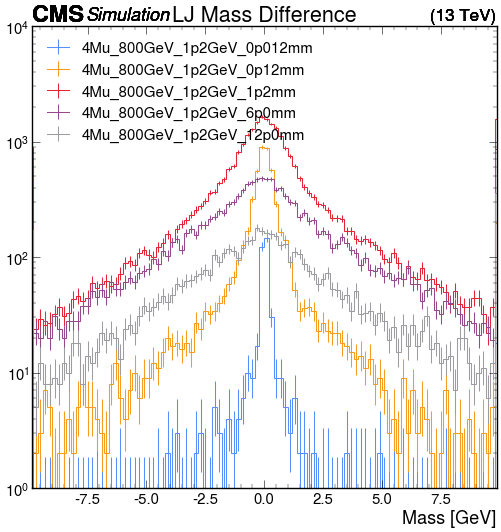

In [52]:
output = coffea.util.load(f"outputs/bkg_38.coffea")
# for thesis
npl = 1
ch = "bkg_2mulj_iso_disp_dphi_ljmp20"
htp = "lj01_massdiff"
plt.subplots(1, npl, figsize=(12, 12))
for sss in fmulxy8:
    utilities.plot(output[sss]["hists"][htp][ch, :], label=sss)
    plt.xlabel("Mass [GeV]")
    plt.title("LJ Mass Difference")
    plt.yscale("log")
    plt.ylim(1, 10000)
    plt.xlim(-9.87, 9.87)
    plt.legend(loc="upper left")
plt.savefig(f"clean_plots/finls_bkg_38_massdiff.pdf", bbox_inches="tight", dpi=300)

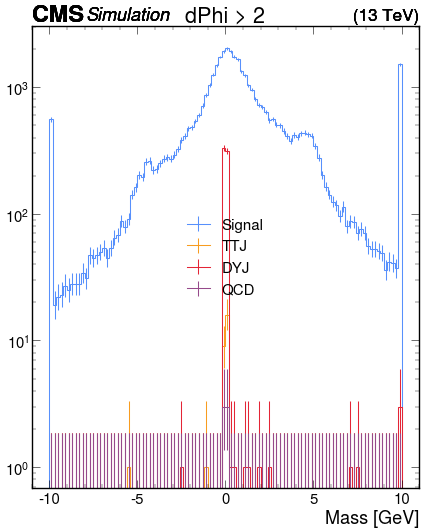

In [26]:
output = coffea.util.load(f"outputs/bkg_38.coffea")
# for thesis
npl = 1
ch1 = "bkg_2mulj_iso_disp_dphi"
ch2 = "bkg_2mulj_iso_disp_dphi_ljmp10"
ch3 = "bkg_2mulj_iso_disp_dphi_ljmp15"
# ch1 = "bkg_base_2mulj_iso_disp_dphi_ljmp3"
    # "bkg_2mulj_iso_disp_dphi_ljmp10",
    # "bkg_2mulj_iso_disp_dphi_ljmp15",
    # "bkg_2mulj_iso_disp_dphi_ljmp20"
    # "bkg_base_2mulj_iso_disp_dphi_mljd_mass175",
# ]
# ch = "bkg_2mulj_iso_disp_dphi_ljmdiff1"
ch = ch3
htp = "lj01_massdiff"
# htp = "lj1_mass"

plt.subplots(1, npl, figsize=(npl*figw, figh))
utilities.plot(output[sss]["hists"][htp][ch, :], label="Signal")
utilities.plot(merge_bkg(output, bkgttj, htp, ch1), label = "TTJ")
utilities.plot(merge_bkg(output, bkgdyj, htp, ch1), label = "DYJ")
utilities.plot(merge_bkg(output, bkgqcd, htp, ch1), label = "QCD")
plt.xlabel("Mass [GeV]")
plt.title("dPhi > 2")
plt.yscale("log")
plt.legend()
# plt.savefig(f"clean_plots/fin_bkg_33_massdiff.pdf", bbox_inches="tight", dpi=300)

In [ ]:
para

## Signal

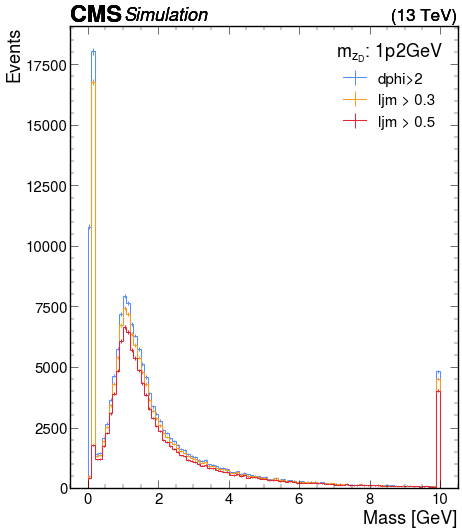

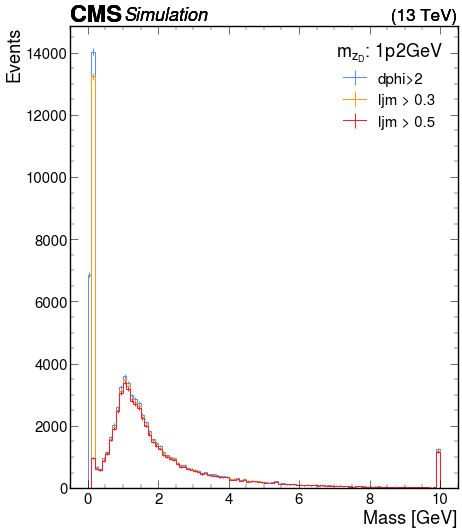

In [27]:
npl = 3
for sss in signal[:1]:
    parts = sss.split("_")
    plt.subplots(1, 1, figsize=(figw, figh))
    # plt.subplot(1, npl, 1)
    for ic, ch in enumerate(chan):
        utilities.plot(output[sss]["hists"]["lj0_mass"][ch, :], label=chaname[ic])
    plt.ylabel("Events")
    plt.xlabel("Mass [GeV]")
    plt.legend(title=f"$m_{{z_D}}$: {parts[2]}")
    plt.savefig(f"clean_plots/finls_bkg_36_lead.pdf", bbox_inches="tight", dpi=300)
    
    plt.subplots(1, 1, figsize=(figw, figh))# plt.subplot(1, npl, 2)
    for ic, ch in enumerate(chan):
        utilities.plot(output[sss]["hists"]["lj1_mass"][ch, :], label=chaname[ic])
    plt.legend(title=f"$m_{{z_D}}$: {parts[2]}")
    plt.xlabel("Mass [GeV]")
    plt.ylabel("Events")
    plt.savefig(f"clean_plots/finls_bkg_36_slead.pdf", bbox_inches="tight", dpi=300)

    # plt.subplot(1, npl, 3)
    # for ic, ch in enumerate(chan):
    #     utilities.plot(output[sss]["hists"]["lj01_massdiff"][ch, :], label=chaname[ic])
    # plt.legend(title=f"$m_{{z_D}}$: {parts[1]} {parts[2]} {parts[3]}")

## Signal + Background

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variance

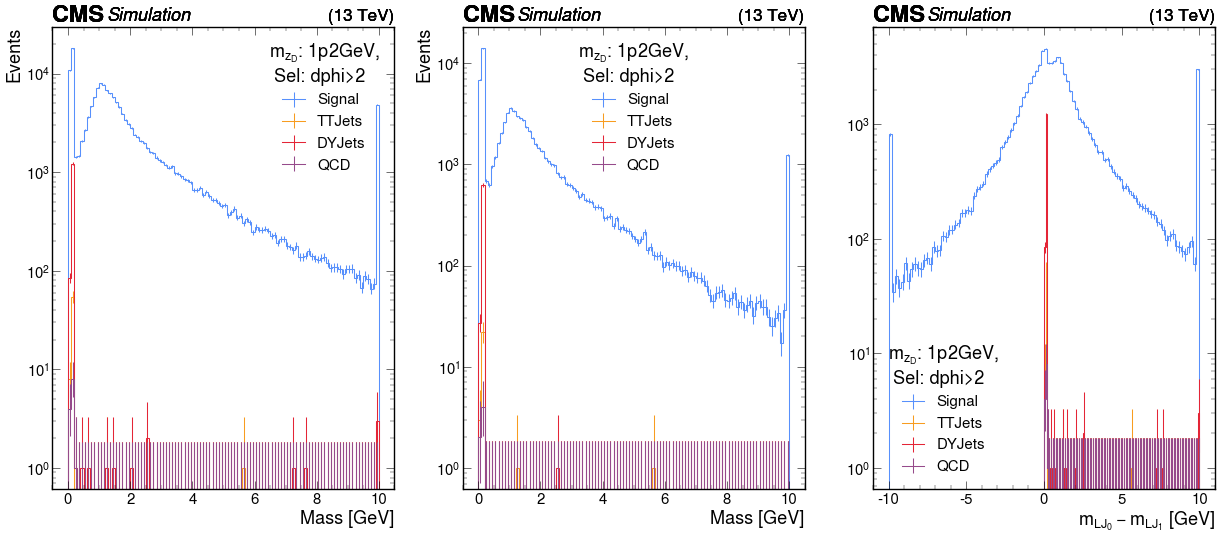

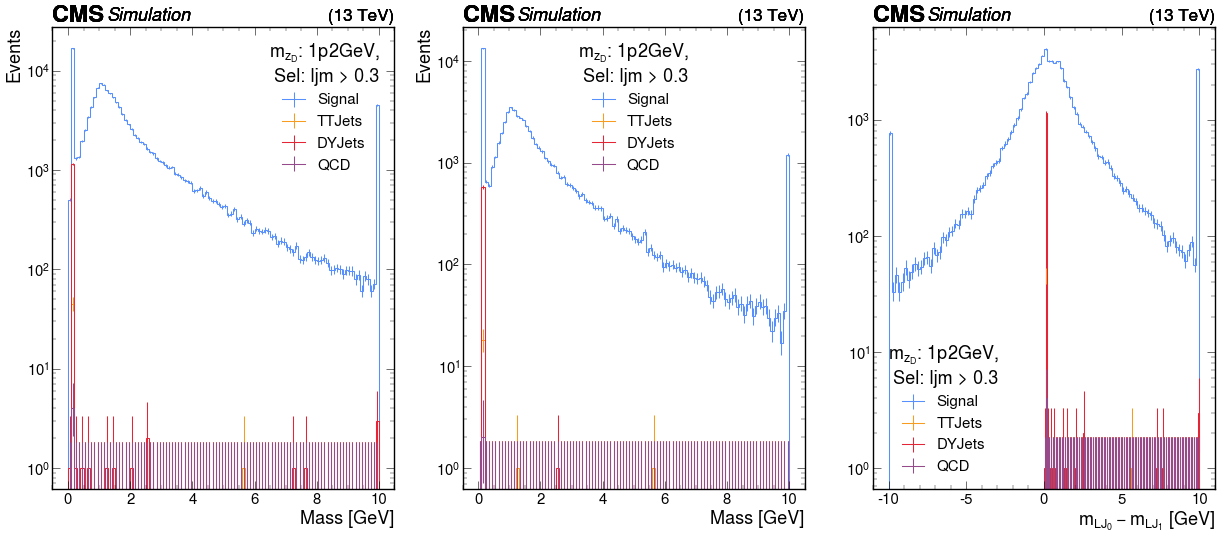

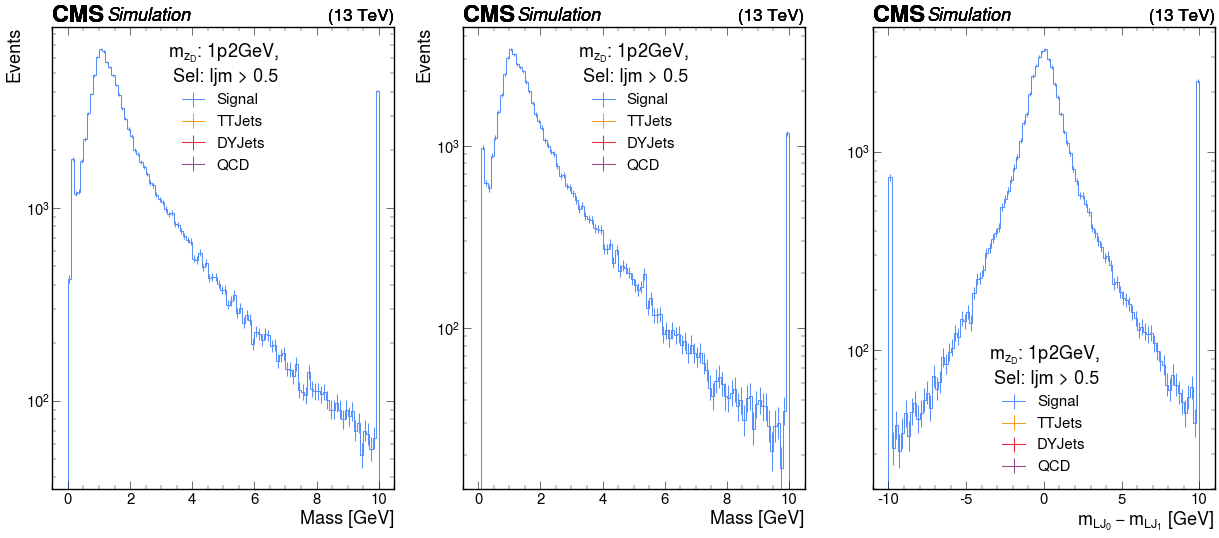

In [28]:
sss = signal[0]
npl = 3
for ic, ch in enumerate(chan):
    
    plt.subplots(1, npl, figsize=(npl*figw, figh))
    plt.subplot(1, npl, 1)
    utilities.plot(output[sss]["hists"]["lj0_mass"][ch, :], label="Signal")
    TTJ = merge_bkg(output, bkgttj, "lj0_mass", ch)
    utilities.plot(TTJ, label = "TTJets")
    DYJ = merge_bkg(output, bkgdyj, "lj0_mass", ch)
    utilities.plot(DYJ, label = "DYJets")
    QCD = merge_bkg(output, bkgqcd, "lj0_mass", ch)
    utilities.plot(QCD, label = "QCD")
    plt.yscale("log")
    plt.xlabel("Mass [GeV]")
    plt.ylabel("Events")
    plt.legend(title=f"$m_{{z_D}}$: {parts[2]},\n Sel: {chaname[ic]}", loc=0)
    # plt.savefig(f"clean_plots/finls_bkg_{ch}_lead.pdf", bbox_inches="tight", dpi=300)
    
    # plt.subplots(1, npl, figsize=(figw, figh))
    plt.subplot(1, npl, 2)
    utilities.plot(output[sss]["hists"]["lj1_mass"][ch, :], label="Signal")
    TTJ = merge_bkg(output, bkgttj, "lj1_mass", ch)
    utilities.plot(TTJ, label = "TTJets")
    DYJ = merge_bkg(output, bkgdyj, "lj1_mass", ch)
    utilities.plot(DYJ, label = "DYJets")
    QCD = merge_bkg(output, bkgqcd, "lj1_mass", ch)
    utilities.plot(QCD, label = "QCD")
    plt.yscale("log")
    plt.xlabel("Mass [GeV]")
    plt.ylabel("Events")
    plt.legend(title=f"$m_{{z_D}}$: {parts[2]},\n Sel: {chaname[ic]}", loc=0)
    # plt.savefig(f"clean_plots/finls_bkg_{ch}_slead.pdf", bbox_inches="tight", dpi=300)
    
    plt.subplot(1, npl, 3)
    utilities.plot(output[sss]["hists"]["lj01_massdiff"][ch, :], label="Signal")
    TTJ = merge_bkg(output, bkgttj, "lj0_mass", ch)
    utilities.plot(TTJ, label = "TTJets")
    DYJ = merge_bkg(output, bkgdyj, "lj0_mass", ch)
    utilities.plot(DYJ, label = "DYJets")
    QCD = merge_bkg(output, bkgqcd, "lj0_mass", ch)
    utilities.plot(QCD, label = "QCD")
    plt.yscale("log")
    plt.legend(title=f"$m_{{z_D}}$: {parts[2]},\n Sel: {chaname[ic]}", loc=0)
    # plt.title()

    # plt.savefig(f"clean_plots/finls_bkg_36_ljmp3.pdf", bbox_inches="tight", dpi=300)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


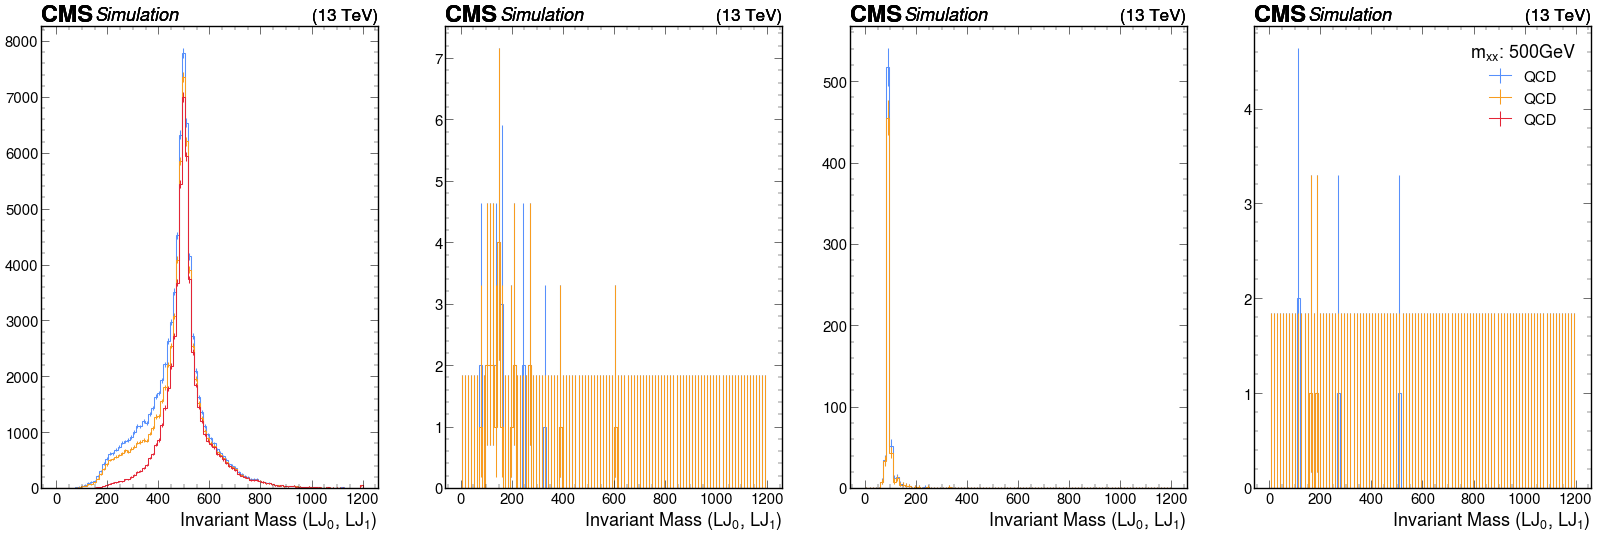

In [29]:
htp = "lj_lj_invmass"
plt.subplots(1, 4, figsize=(4*figw, figh))
for ic, ch in enumerate(chan):
    plt.subplot(1, 4, 1)
    utilities.plot(output[sss]["hists"][htp][ch, :], label=chaname[ic])
    plt.subplot(1, 4, 2)
    TTJ = merge_bkg(output, bkgttj, htp, ch)
    utilities.plot(TTJ, label = "TTJets")
    plt.subplot(1, 4, 3)
    DYJ = merge_bkg(output, bkgdyj, htp, ch)
    utilities.plot(DYJ, label = "DYJets")
    plt.subplot(1, 4, 4)
    QCD = merge_bkg(output, bkgqcd, htp, ch)
    utilities.plot(QCD, label = "QCD")
    # parts = sss.split("_")
    # plt.subplots(1, npl, figsize=(npl*figw, figh))
    # plt.subplot(1, npl, 1)
    # for ic, ch in enumerate(chan):
    #     utilities.plot(output[sss]["hists"]["lj0_mass"][ch, :], label=chaname[ic])
    # plt.legend(title=f"$m_{{z_D}}$: {parts[2]}")
    
    # plt.subplot(1, npl, 2)
    # for ic, ch in enumerate(chan):
    #     utilities.plot(output[sss]["hists"]["lj1_mass"][ch, :], label=chaname[ic])
    # plt.legend(title=f"$m_{{z_D}}$: {parts[2]}")

    # plt.subplot(1, npl, 3)
    # for ic, ch in enumerate(chan):
    #     utilities.plot(output[sss]["hists"]["lj01_massdiff"][ch, :], label=chaname[ic])
    plt.legend(title=f"$m_{{xx}}$: {parts[1]}")

# Background Only

['DYJetsToMuMu_M10to50', 'DYJetsToMuMu_M50']


/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


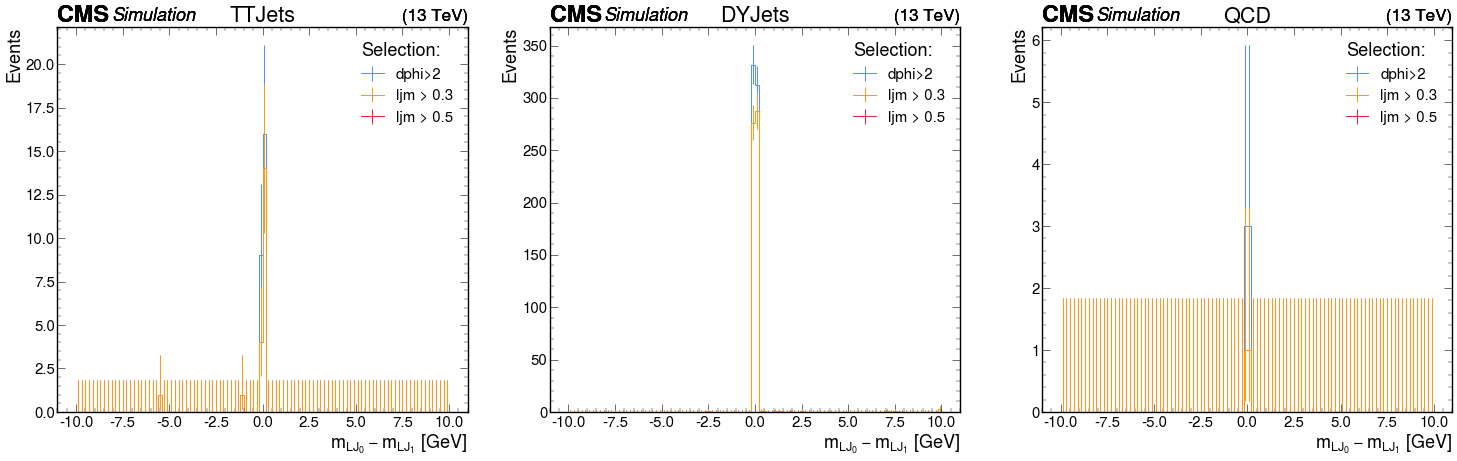

In [30]:
htp = "lj01_massdiff"
plt.subplots(1, 3, figsize=(3*figh, figw))
npl = 3
print(bkgdyj)
for ij, ch in enumerate(chan):
    plt.subplot(1, npl, 1)
    TTJ = merge_bkg(output, bkgttj, htp, ch)
    utilities.plot(TTJ, label = chaname[ij])
    plt.title("TTJets")
    plt.ylabel("Events")
    plt.legend(title=r"Selection:", alignment="left", loc=0)
    
    plt.subplot(1, npl, 2)
    DYJ = merge_bkg(output, bkgdyj, htp, ch)
    utilities.plot(DYJ, label = chaname[ij])
    plt.title("DYJets")
    plt.ylabel("Events")
    plt.legend(title=r"Selection:", alignment="left", loc=0)
    
    plt.subplot(1, npl, 3)
    QCD = merge_bkg(output, bkgqcd, htp, ch)
    utilities.plot(QCD, label = chaname[ij])
    plt.title("QCD")
    plt.ylabel("Events")
    # plt.yscale("log")
    plt.legend(title=r"Selection:", alignment="left", loc=0)

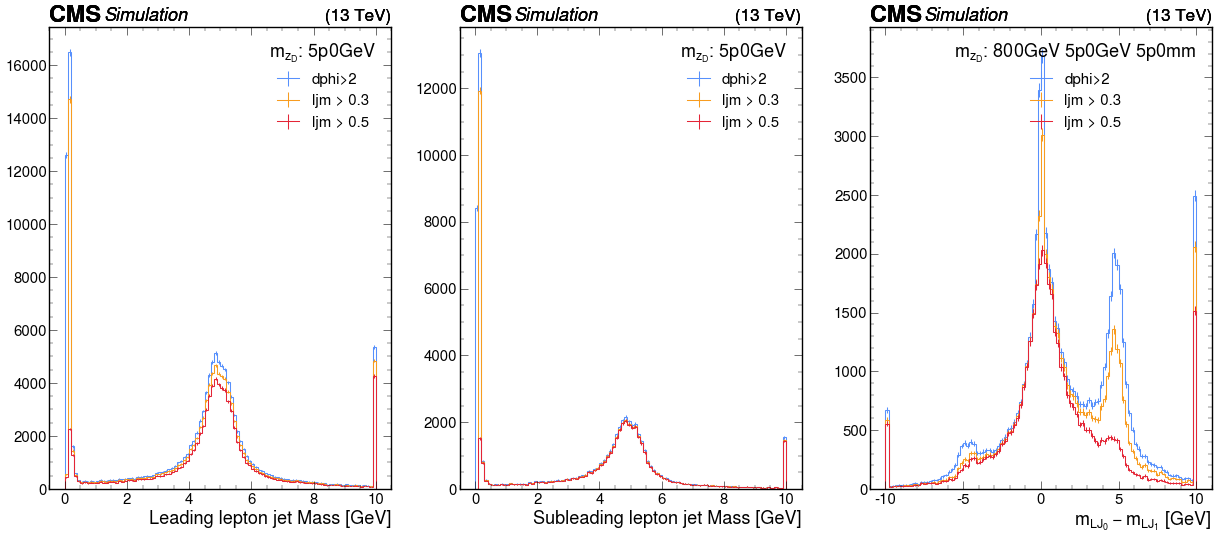

In [31]:
npl = 3
for sss in signal[2:3]:
    parts = sss.split("_")
    plt.subplots(1, npl, figsize=(npl*figw, figh))
    plt.subplot(1, npl, 1)
    for ic, ch in enumerate(chan):
        utilities.plot(output[sss]["hists"]["lj0_mass"][ch, :], label=chaname[ic])
    plt.legend(title=f"$m_{{z_D}}$: {parts[2]}")
    
    plt.subplot(1, npl, 2)
    for ic, ch in enumerate(chan):
        utilities.plot(output[sss]["hists"]["lj1_mass"][ch, :], label=chaname[ic])
    plt.legend(title=f"$m_{{z_D}}$: {parts[2]}")

    plt.subplot(1, npl, 3)
    for ic, ch in enumerate(chan):
        utilities.plot(output[sss]["hists"]["lj01_massdiff"][ch, :], label=chaname[ic])
    plt.legend(title=f"$m_{{z_D}}$: {parts[1]} {parts[2]} {parts[3]}")

In [32]:
npl = 1
plt.subplots(1, npl, figsize=(npl*figw, figh))
for ic, ch in enumerate(chan[:1]):
    # print(sss)
    # plt.subplot(1, npl, 1)
    # utilities.plot(output[sss]["hists"]["lj0_mass"][ch, :], label=chaname[ic])
    # # utilities.plot(output["TTJets"]["hists"]["lj0_mass"][ch, :], label="ttjets")
    # # utilities.plot(output[sss]["hists"]["lj1_mass"][ch, :], label="lj1",)
    # plt.xlabel("Mass [GeV]")
    # plt.yscale("log")
    # plt.title("lj0")
    # plt.legend()
    
    # plt.subplot(1, npl, 2)
    # # utilities.plot(output[sss]["hists"]["lj0_mass"][ch2, :], label="lj0 cut",)
    # utilities.plot(output[sss]["hists"]["lj1_mass"][ch, :], label=chaname[ic])
    # plt.xlabel("Mass [GeV]")
    # plt.yscale("log")
    # plt.title("lj1")
    # plt.legend()
    
    plt.subplot(1, npl, 1)
    # utilities.plot(output[sss]["hists"]["lj01_massdiff"][ch1, :], label="lj_mass diff no cut")
    utilities.plot(output[sss]["hists"]["lj01_massdiff"][ch, :], label=chaname[ic])
    QCD = merge_bkg(output, bkgqcd, htp, ch)
        utilities.plot(QCD, label = chaname[ij])
    # utilities.plot(output["TTJets"]["hists"]["lj01_massdiff"][ch, :], label=ch)  
    
    # # utilities.plot(out[sss]["hists"]["lj01_massdiff"][ch3, :], label="lj_mass diff ch3")
    
    # # utilities.plot(out[sss]["hists"]["mulj01_massdiff"][ch1, :], label="mulj_mass diff")
    plt.xlabel("Mass [GeV]")
    plt.title("mass diff")
    # plt.yscale("log")
    plt.legend()
# plt.savefig(f"clean_plots/fin_bkg_33_massdiff.pdf", bbox_inches="tight", dpi=300)

IndentationError: unexpected indent (309273133.py, line 26)

In [ ]:
npl = 3
plt.subplots(1, npl, figsize=(npl*figw, figh))
for ch in chan:
    plt.subplot(1, npl, 1)
    utilities.plot(output[sss]["hists"]["mulj0_mass"][ch, :], label=ch)
    # utilities.plot(output[sss]["hists"]["lj1_mass"][ch, :], label="lj1",)
    plt.xlabel("Mass [GeV]")
    plt.yscale("log")
    plt.title("mulj0")
    plt.legend()
    
    plt.subplot(1, npl, 2)
    # utilities.plot(output[sss]["hists"]["lj0_mass"][ch2, :], label="lj0 cut",)
    utilities.plot(output[sss]["hists"]["mulj1_mass"][ch, :], label=ch,)
    plt.xlabel("Mass [GeV]")
    plt.yscale("log")
    plt.title("mulj1")
    plt.legend()
    
    plt.subplot(1, npl, 3)
    # utilities.plot(output[sss]["hists"]["lj01_massdiff"][ch1, :], label="lj_mass diff no cut")
    utilities.plot(output[sss]["hists"]["mulj01_massdiff"][ch, :], label=ch)
    
    # # utilities.plot(out[sss]["hists"]["lj01_massdiff"][ch3, :], label="lj_mass diff ch3")
    
    # # utilities.plot(out[sss]["hists"]["mulj01_massdiff"][ch1, :], label="mulj_mass diff")
    plt.xlabel("Mass [GeV]")
    plt.title("mass diff")
    # plt.yscale("log")
    plt.legend()
# plt.savefig(f"clean_plots/fin_bkg_33_massdiff.pdf", bbox_inches="tight", dpi=300)

In [ ]:
histoplot = ["lj_lj_invmass",]
colsig=["black", "darkviolet", "navy", "magenta", "darkorange", "darkblue"]
labl = ["0p3", "3p0", "30", "150", "300"]
# sss = signal[1]

In [ ]:
wmu, mxx, mzd, ctau = sss.split("_")
# print(wmu, mxx, mzd, ctau)
# print(chan)
for ik, htp in enumerate(histoplot):
    plt.subplots(1, 1, figsize=(figh, figw))
    for ij, ch in enumerate(chan):
        utilities.plot(output[sss]["hists"][htp][ch, :], label = chaname[ij])
    plt.title("Signal")
    plt.ylabel("Events")
    plt.xlabel("Mass [GeV]")
    plt.yscale("log")
    plt.legend(title=r"Selection:", alignment="left", loc=0)
    plt.text(0.05, 0.95,
             f"{wmu}\n"
             f"m$_{{XX}}$ = {mxx} \n"
             f"m$_{{Z_D}}$ = {mzd} \n"
             "$l_{xy}$ = 30cm",
             transform=plt.gca().transAxes,
             fontsize=24,
             va="top"
            )
# if (save):plt.savefig(f"clean_plots/fin_bkg_cuts_{vr}_{sisa}_SIG.pdf", bbox_inches="tight", dpi=300)

# TTJets
for ik, htp in enumerate(histoplot):
    plt.subplots(1, 1, figsize=(figh, figw))
    for ij, ch in enumerate(chan):
        TTJ = merge_bkg(output, bkgttj, htp, ch)
        utilities.plot(TTJ, label = chaname[ij])
    plt.title("TTJets")
    plt.xlabel("Mass [GeV]")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"Selection:", alignment="left", loc=0)
# if (save): plt.savefig(f"clean_plots/fin_bkg_cuts_{vr}_{sisa}_TTJ.pdf", bbox_inches="tight", dpi=300)
    
# DYJets
for ik, htp in enumerate(histoplot):
    plt.subplots(1, 1, figsize=(figh, figw))
    for ij, ch in enumerate(chan):
        DYJ = merge_bkg(output, bkgdyj, htp, ch)
        utilities.plot(DYJ, label = chaname[ij])
    plt.title("DYJets")
    plt.xlabel("Mass [GeV]")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"Selection:", alignment="left", loc=0)
# if (save): plt.savefig(f"clean_plots/fin_bkg_cuts_{vr}_{sisa}_DYJ.pdf", bbox_inches="tight", dpi=300)

# QCD
for ik, htp in enumerate(histoplot):
    plt.subplots(1, 1, figsize=(figh, figw))
    for ij, ch in enumerate(chan):
        QCD = merge_bkg(output, bkgqcd, htp, ch)
        utilities.plot(QCD, label = chaname[ij])
    plt.title("QCD")
    plt.xlabel("Mass [GeV]")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"Selection:", alignment="left", loc=0)
# if (save): plt.savefig(f"clean_plots/fin_bkg_cuts_{vr}_{sisa}_QCD.pdf", bbox_inches="tight", dpi=300)

In [ ]:
####### Stacking Backgrounds diff selections
# chan = [ch1, ch2]
for htp in histoplot:  
    for ic, ch in enumerate(chan):
        
        fig, ax = plt.subplots(figsize=(figh, figw))
        
        TTJ = merge_bkg(output, bkgttj, htp, ch)
        DYJ = merge_bkg(output, bkgdyj2, htp, ch)
        QCD = merge_bkg(output, bkgqcd11, htp, ch)
    
        # Backgrounds
        hep.histplot([TTJ, DYJ, QCD,],
                     stack=True,  histtype="fill", 
                     color=["#E74C3C", "#FFD700", "#3498DB"],
                     label=["TTJ", "DYJ", "QCD"],
                     ax=ax, )
        
        # Signal
        for ix, sss in enumerate(signal):
            hep.histplot(output[sss]["hists"][htp][ch, ::2j],  color=colsig[ix], label=labl[ix], histtype="step", linewidth=2, ax=ax)
        hep.cms.label(data=False, lumi=None, com=13, ax=ax)
        # ax.set_ylim(1, 1000000)
        # ax.yscale(1,10000)
        ax.set_xlabel("Mass [GeV]")
        ax.set_ylabel("Events")
        ax.set_yscale("log")
        ax.legend(title="Process", ncol=2)
        plt.title(f"selection: {chaname[ic]}")
        # if (save): 
        #     plt.savefig(f"clean_plots/fin_bkg_stack_{vr}_{sisa}_{htp}_{chaname[ic]}.pdf", bbox_inches="tight", dpi=300)
            # print(f"saving: fin_bkg_stack_{vr}_{sisa}_{htp}_{chaname[ic]}_mxx.pdf")
        # print(f"clean_plots/fin_bkg_stack_{vr}_{htp}_{chaname[ic]}_mxx")

In [ ]:
####### Stacking Backgrounds diff selections

histoplot = ["lj0_mass"]
for htp in histoplot:  
    for ic, ch in enumerate(chan):
        
        fig, ax = plt.subplots(figsize=(figh, figw))
        
        TTJ = merge_bkg(output, bkgttj, htp, ch)
        DYJ = merge_bkg(output, bkgdyj2, htp, ch)
        QCD = merge_bkg(output, bkgqcd11, htp, ch)
    
        # Backgrounds
        hep.histplot([TTJ, DYJ, QCD,],
                     stack=True,  histtype="fill", 
                     color=["#E74C3C", "#FFD700", "#3498DB"],
                     label=["TTJ", "DYJ", "QCD"],
                     ax=ax, )
        
        # Signal
        for ix, sss in enumerate(signal):
            hep.histplot(output[sss]["hists"][htp][ch, ::2j],  color=colsig[ix], label=labl[ix], histtype="step", linewidth=2, ax=ax)
        hep.cms.label(data=False, lumi=None, com=13, ax=ax)
        # ax.set_ylim(1, 1000000)
        # ax.yscale(1,10000)
        ax.set_xlabel("Mass [GeV]")
        ax.set_ylabel("Events")
        ax.set_yscale("log")
        ax.legend(title="Process", ncol=2)
        plt.title(f"selection: {chaname[ic]}")
        # if (save): 
        #     plt.savefig(f"clean_plots/fin_bkg_stack_{vr}_{sisa}_{htp}_{chaname[ic]}.pdf", bbox_inches="tight", dpi=300)
            # print(f"saving: fin_bkg_stack_{vr}_{sisa}_{htp}_{chaname[ic]}_mxx.pdf")
        # print(f"clean_plots/fin_bkg_stack_{vr}_{htp}_{chaname[ic]}_mxx")

In [ ]:
ch = channels[-1]#"bkg_base_2mulj_iso_disp_dphi_mass175"
# print(ch)
# signal = fmulxy4 + fmulxy5 + fmulxy6 + fmulxy7 + fmulxy8 + fmulxy9 + fmulxy0 + fmulxyi + fmulxyx
# "bkg_base_2mulj_iso_disp_dphi",
# "bkg_base_2mulj_iso_disp_dphi_ljmp3",
# "bkg_base_2mulj_iso_disp_dphi_ljmp5",
# "bkg_base_2mulj_iso_disp_dphi_ljmp3_ljmljm1"

# cut = "ljljMass > 175"
cuts = ["LJ-LJ dPhi > 2", "ljmass > 0.3", "abs(lj01 massdiff) < 1.0"]#"ljmass > 0.5"] # for run 36

print(f"{'Sample':<30} {'Yield':>12}")
for cut in cuts:
    print(f"selection: {cut}\n")
    # signal yields
    for im, sample in enumerate(signal):
        print(f"{sample:<30}: {output[sample]['cutflow'][ch].rows[cut]['weighted']:>12.2f}")
    print()
    # Background yields
    dyj = merge_cutflows(output, bkgdyj, ch)
    ttj = merge_cutflows(output, bkgttj, ch)
    qcd = merge_cutflows(output, bkgqcd, ch)
       
    print(f"{'TTJets':<30} {ttj[cut]['weighted']:>12.2f}")
    # print("-" * 44)
    print(f"{'DYJ':<30}    {dyj[cut]['weighted']:>12.2f}")
    # print("-" * 44)
    print(f"{'QCD':<30}    {qcd[cut]['weighted']:>12.2f}")
    print("-----------------------------------------------------------------------------------------\n")

# save yield in a text file for combine

In [ ]:
mxx_map = {"500GeV": "2", "800GeV": "3", "1000GeV": "4"}
mzd_map = {"0p25GeV": "1", "1p2GeV": "2", "5p0GeV": "3"}

cut = "ljljMass > 175"
ch = channels[-1]
groups = [
    # fmulxy4,
    # fmulxy5,
    fmulxy6,
    fmulxy7,
    fmulxy8,
    fmulxy9,
    fmulxy0,
    fmulxyi,
    fmulxyx,
]
# print(signal)
with open(f"combine_inputs_{vr}.txt", "w") as fout:

    for group in signal:
        # print(group)
        for ctau_idx, sample in enumerate(group, start=1):
            # print(sample)
            yld = output[sample]['cutflow'][ch].rows[cut]['weighted']

            _, mxx, mzd, _ = sample.split("_")

            identifier = (
                mxx_map[mxx]
                + mzd_map[mzd]
                + str(ctau_idx)
            )

            fout.write(f"_fmu_{vr}_{identifier} {yld:.2f}\n")

# Raw number after each selection

In [ ]:
import matplotlib.pyplot as plt

yield_sig1 = [1.71, 1.71, 0.77]
yield_sig2 = [24.21, 24.16, 5.82]
yield_sig3 = [218.23, 217.40, 25.92]
yield_sig4 = [126.10, 124.42, 23.81]
yield_sig5 = [84.88, 83.13, 20.0]

yield_tt = [225.3, 150.19, 120.5]
yield_dy = [953.7, 433.5, 300]
yield_qcd = [1.07, 0.8, 0.5]

selections = [r"$m_{xx}$>150", r"$m_{xx}$ > 175", r"$m_{lj1} - m_{lj2}$ <0.2"]

plt.figure(figsize=(16,10))

plt.plot(selections, yield_sig1, marker='o', linewidth=2, label=r"$L_{xy} = 0.3 cm$")
plt.plot(selections, yield_sig2, marker='s', linewidth=2, label=r"$L_{xy} = 3 cm$")
plt.plot(selections, yield_sig3, marker='^', linewidth=2, label=r"$L_{xy} = 30 cm$")
plt.plot(selections, yield_sig4, marker='D', linewidth=2, label=r"$L_{xy} = 150 cm$")
plt.plot(selections, yield_sig5, marker='v', linewidth=2, label=r"$L_{xy} = 300 cm$")
plt.plot(selections, yield_tt, marker='*', linewidth=2, label='TTJ')
plt.plot(selections, yield_dy, marker='P', linewidth=2, label='DYJ')
plt.plot(selections, yield_qcd, marker='X', linewidth=2, label='QCD')

plt.xlabel("Selection")
plt.ylabel("Yield")
plt.title("Signal Yields After Each Selection mxx = 800, mzd = 1.2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

\begin{equation}
\mathrm{SIF}
=
\frac{\epsilon_S}{\sqrt{\epsilon_B}}
\end{equation}

In [ ]:
import numpy as np
import pandas as pd

signals = {
    "Sig1": [1.71, 1.71, 0.77],
    "Sig2": [24.21, 24.16, 5.82],
    "Sig3": [218.23, 217.40, 25.92],
    "Sig4": [126.10, 124.42, 23.81],
    "Sig5": [84.88, 83.13, 20.00],
}

background = np.array([
    225.3 + 953.7 + 1.07,
    150.19 + 433.5 + 0.8,
    120.5 + 300 + 0.5
])

eps_b = background / background[0]

selections = ["Baseline", "Selection 1", "Selection 2"]

df = pd.DataFrame(index=signals.keys(), columns=selections)

for sig, y in signals.items():
    eps_s = np.array(y) / y[0]
    df.loc[sig] = eps_s / np.sqrt(eps_b)

print("Significance Improvement Factor")
display(df.astype(float).round(3))

# signal events surviving each selection: $\epsilon_S = \frac{S_b}{S_a}$

In [ ]:
import numpy as np
import pandas as pd

signals = {
    "Sig1": [1.71, 1.71, 0.77],
    "Sig2": [24.21, 24.16, 5.82],
    "Sig3": [218.23, 217.40, 25.92],
    "Sig4": [126.10, 124.42, 23.81],
    "Sig5": [84.88, 83.13, 20.00],
}

selections = ["Baseline", "Selection 1", "Selection 2"]

df = pd.DataFrame(index=signals.keys(), columns=selections)

for sig, y in signals.items():
    df.loc[sig] = np.array(y) / y[0]

print("Signal Efficiency")
display(df.astype(float).round(3))

# Background events surviving each selection:  $\epsilon_B = \frac{B_b}{B_a}$ 

In [ ]:
import numpy as np
import pandas as pd

backgrounds = {
    "TT": [225.3, 150.19, 120.5],
    "DY": [953.7, 433.5, 300],
    "QCD": [1.07, 0.8, 0.5],
}

selections = ["Baseline", "Selection 1", "Selection 2"]

df = pd.DataFrame(index=backgrounds.keys(), columns=selections)

for bkg, y in backgrounds.items():
    df.loc[bkg] = np.array(y) / y[0]

print("Background Efficiency")
display(df.astype(float).round(3))

In [ ]:
# Background rejection 1 - e_B
# backgrounds = {
#     "TT": [225.3, 150.19, 120.5],
#     "DY": [953.7, 433.5, 300],
#     "QCD": [1.07, 0.8, 0.5],
# }

# selections = ["Baseline", "Selection 1", "Selection 2"]

# df = pd.DataFrame(index=backgrounds.keys(), columns=selections)

# for bkg, y in backgrounds.items():
#     eff = np.array(y) / y[0]
#     df.loc[bkg] = 1 - eff

# print("Background Rejection")
# display(df.astype(float).round(3))

# signal to background ratio: $I = \frac{\epsilon_S}{\epsilon_B}$
# I > 1 good
# I = 1 ummm
# I < 1 bad

In [ ]:
# Signal to background ratio

signals = {
    "Sig1": [1.71, 1.71, 0.77],
    "Sig2": [24.21, 24.16, 5.82],
    "Sig3": [218.23, 217.40, 25.92],
    "Sig4": [126.10, 124.42, 23.81],
    "Sig5": [84.88, 83.13, 20.00],
}

background = np.array([
    225.3 + 953.7 + 1.07,
    150.19 + 433.5 + 0.8,
    120.5 + 300 + 0.5
])

eps_b = background / background[0]

selections = ["Baseline", "Selection 1", "Selection 2"]

df = pd.DataFrame(index=signals.keys(), columns=selections)

for sig, y in signals.items():
    eps_s = np.array(y) / y[0]
    df.loc[sig] = eps_s / eps_b

print("Signal-to-Background Ratio")
display(df.astype(float).round(3))